In [140]:
import matplotlib.pyplot as plt
import random
from sklearn.datasets import make_blobs
import numpy as np
import time
RANDOM_SEED = 1
random.seed(RANDOM_SEED)

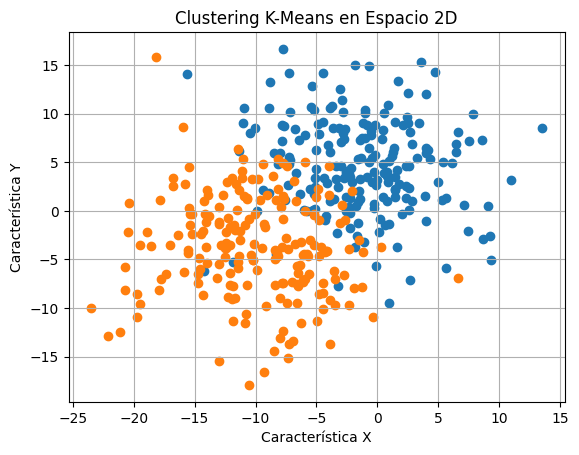

In [141]:
SAMPLES = 400
CLUSTERS_QUANTITY = 2
CLUSTERS_NOISE = 5
X, Y = make_blobs(n_samples=SAMPLES, centers=CLUSTERS_QUANTITY, cluster_std=CLUSTERS_NOISE, random_state=RANDOM_SEED)

for label in set(Y):
  data_label_filtered = [X[i] for i in range(len(X)) if Y[i]==label]
  data_x = [d[0] for d in data_label_filtered]
  data_y = [d[1] for d in data_label_filtered]
  plt.scatter(data_x, data_y)

plt.title('Clustering K-Means en Espacio 2D')
plt.xlabel('Característica X')
plt.ylabel('Característica Y')
plt.grid(True)
plt.show()

#k-vecinos intento 1

In [142]:
class punto:
  def __init__ (self,x,y,grupo = None,distancia = 0):
    self.x = x
    self.y = y
    self.grupo = grupo
    self.distancia = distancia
  def __lt__(self,otro):
    return self.distancia < otro.distancia
  def __repr__(self):
    return f"punto({self.x}, {self.y}, distancia={self.distancia}), grupo={self.grupo})"

def fun(p_ini,k):
  #inicio = time.time()
  lista = []
  puntos = []
  for a, gr in zip(X, Y):
    puntos.append(punto(a[0], a[1], gr))
  for i in range(1,16):
    for a in puntos:
      if a in lista:
        continue
      dis = ((a.y - p_ini.y)**2 + (a.x-p_ini.x)**2)**(1/2)

      if dis <= i + min(p_ini.x,p_ini.y):
        a.distancia = dis
        lista.append(a)
    lista.sort()
    if len(lista) >=k:
      #fin = time.time()
      #l = fin-inicio
      return lista[:k]#, l

p = punto(10,10)
fun(p,4)

[punto(7.863733635756386, 9.961773361645685, distancia=2.136608353179988), grupo=0),
 punto(8.596307308338702, 7.334799869705074, distancia=3.0122491442686865), grupo=0),
 punto(7.514028227299914, 7.22840414631473, distancia=3.7231437295418757), grupo=0),
 punto(13.494725655911633, 8.52941299401045, distancia=3.791534458800593), grupo=0)]

#Intento 2

In [143]:
class punto:
  def __init__ (self,x,y,grupo = None,distancia = 0):
    self.x = x
    self.y = y
    self.grupo = grupo
    self.distancia = distancia
  def __lt__(self,otro):
    return self.distancia < otro.distancia
  def __repr__(self):
    return f"punto({self.x}, {self.y}, distancia={self.distancia}), grupo={self.grupo})"

def fun2(p_ini,k):
  #inicio = time.time()
  lista=[]
  puntos = []
  for a, gr in zip(X, Y):
    puntos.append(punto(a[0], a[1], gr))
  for i in puntos:
    dis = ((i.x-p_ini.x)**(2) + (i.y - p_ini.y)**2)**(1/2)
    i.distancia = dis
    lista.append(i)
  lista.sort()
  #fin = time.time()
  #l = fin-inicio
  return lista[:k] #,l
fun2(p,11)

[punto(7.863733635756386, 9.961773361645685, distancia=2.136608353179988), grupo=0),
 punto(8.596307308338702, 7.334799869705074, distancia=3.0122491442686865), grupo=0),
 punto(7.514028227299914, 7.22840414631473, distancia=3.7231437295418757), grupo=0),
 punto(13.494725655911633, 8.52941299401045, distancia=3.791534458800593), grupo=0),
 punto(6.6394509796008325, 8.11671067172984, distancia=3.852280936339155), grupo=0),
 punto(6.425188088337981, 6.920194278842683, distancia=4.718525562486019), grupo=0),
 punto(6.478693859796012, 6.0965483517155405, distancia=5.257045910350505), grupo=0),
 punto(3.998587031308615, 12.005573950954155, distancia=6.327660270077954), grupo=0),
 punto(6.134467797150777, 4.953503350970302, distancia=6.3568441572790135), grupo=0),
 punto(3.3910759807251027, 9.006579535081977, distancia=6.683169974844767), grupo=0),
 punto(5.378140095257623, 5.051997767396789, distancia=6.770843010505529), grupo=0)]

# predecir un nuevo punto (x,y) a que segmento pertenece

In [144]:
def predecir(p_ini,k):
  lista2 = fun2(p_ini,k)
  con_par = 0
  con_impar = 0
  for i in range(len(lista2)):
    if lista2[i].grupo == 1:
      con_impar += 1
    if lista2[i].grupo == 0 :
      con_par +=1
  if con_par < con_impar :
    p_ini.grupo = 1
  else:
    p_ini.grupo = 0
  return p_ini
p = punto(-15,-10)
predecir(p,2)

punto(-15, -10, distancia=0), grupo=1)

# Graficar

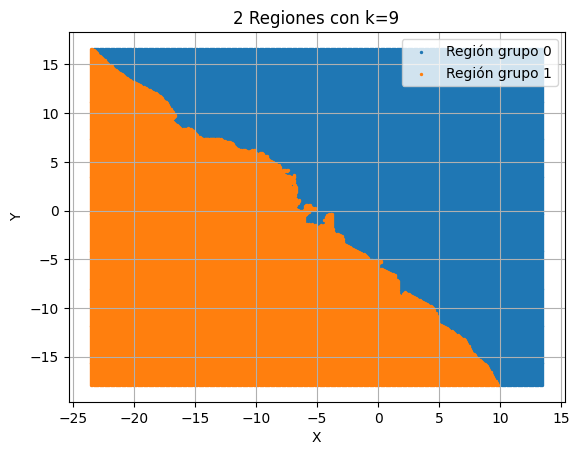

In [147]:
def graficar(k):

  xmin = X[:, 0].min()
  xmax = X[:, 0].max()
  ymin = X[:, 1].min()
  ymax = X[:, 1].max()
  xs = np.arange(xmin, xmax, 0.1)
  ys = np.arange(ymin, ymax, 0.1)
  xx, yy = np.meshgrid(xs, ys)
  distancias = np.sqrt(
    (np.column_stack((xx.ravel(), yy.ravel()))[:, 0, None] - X[:, 0])**2 +
    (np.column_stack((xx.ravel(), yy.ravel()))[:, 1, None] - X[:, 1])**2)

  indices = np.argpartition(distancias, k, axis=1)[:, :k]
  grupos = Y[indices]
  cantidad_1 = np.sum(grupos == 1, axis=1)
  cantidad_0 = np.sum(grupos == 0, axis=1)

  predicciones = np.where(cantidad_1 > cantidad_0, 1, 0)
  plt.scatter(
    np.column_stack((xx.ravel(), yy.ravel()))[predicciones == 0, 0],
    np.column_stack((xx.ravel(), yy.ravel()))[predicciones == 0, 1],
    s=2,
    label="Región grupo 0")

  plt.scatter(
    np.column_stack((xx.ravel(), yy.ravel()))[predicciones == 1, 0],
    np.column_stack((xx.ravel(), yy.ravel()))[predicciones == 1, 1],
    s=2,
    label="Región grupo 1")
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.title(f"2 Regiones con k={k}")
  plt.legend()
  plt.grid()
  plt.show()
graficar(9)